# EDA: OEWS Occupation Panel (2015-2024)

Exploratory analysis of the annual occupation-level employment/wage panel built by `data/fetch_oews.py` and `src/build_features.py`. See `docs/METHODOLOGY.md` for why this is annual (not monthly) and how Florida rows are identified across BLS's shifting column formats.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
df = pd.read_csv("../data/processed/oews_occupation_features.csv")
print(f"{len(df):,} rows, {df['occ_code'].nunique()} unique occupation codes, years {df['year'].min()}-{df['year'].max()}")
df.head()


15,967 rows, 965 unique occupation codes, years 2015-2024


,year,region,occ_code,occ_title,employment_level,wage_hourly_mean,wage_annual_mean,wage_hourly_median,wage_annual_median,wage_annual_pct10,wage_annual_pct90,employment_change_yoy_pct,wage_growth_yoy_pct,employment_change_5yr_cagr,wage_growth_5yr_cagr,contraction_flag_12mo
0,2015,FL,11-1011,Chief Executives,13970.0,97.26,202300.0,NaN,NaN,88650.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2016,FL,11-1011,Chief Executives,14120.0,102.15,212460.0,99.52,207000.0,89510.0,NaN,1.073729,5.022244,NaN,NaN,0.0
2,2017,FL,11-1011,Chief Executives,19350.0,94.08,195680.0,87.67,182360.0,62410.0,NaN,37.039660,-7.897957,NaN,NaN,0.0
3,2018,FL,11-1011,Chief Executives,20860.0,90.32,187870.0,82.21,171000.0,53110.0,NaN,7.803618,-3.991210,NaN,NaN,0.0
4,2019,FL,11-1011,Chief Executives,26300.0,87.02,181000.0,79.14,164620.0,50030.0,NaN,26.078619,-3.656784,NaN,NaN,0.0


## Employment size distribution

Occupation employment is heavily right-skewed — this is the reason the forecasting model (see `notebooks/02_model_evaluation.ipynb`) had to predict growth *rate* rather than absolute level.

count    8.310000e+02
mean     1.855431e+05
std      4.444953e+05
min      1.800000e+02
25%      1.434000e+04
50%      4.200000e+04
75%      1.471350e+05
max      3.988140e+06
Name: employment_level, dtype: float64


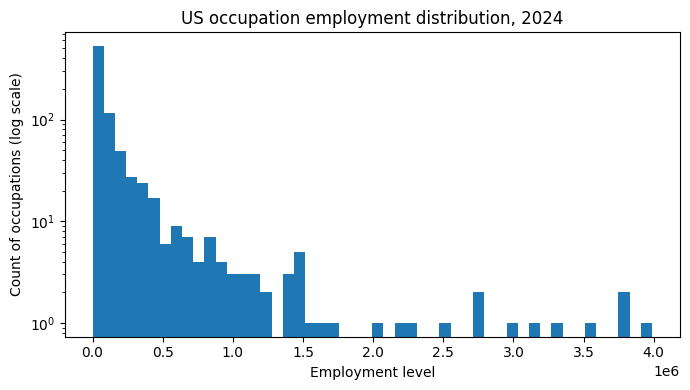

In [2]:
latest = df[(df["year"] == df["year"].max()) & (df["region"] == "US")]
print(latest["employment_level"].describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(latest["employment_level"].dropna(), bins=50, log=True)
ax.set_xlabel("Employment level")
ax.set_ylabel("Count of occupations (log scale)")
ax.set_title(f"US occupation employment distribution, {int(latest['year'].iloc[0])}")
plt.tight_layout()
plt.show()


## Wage distribution (nominal)

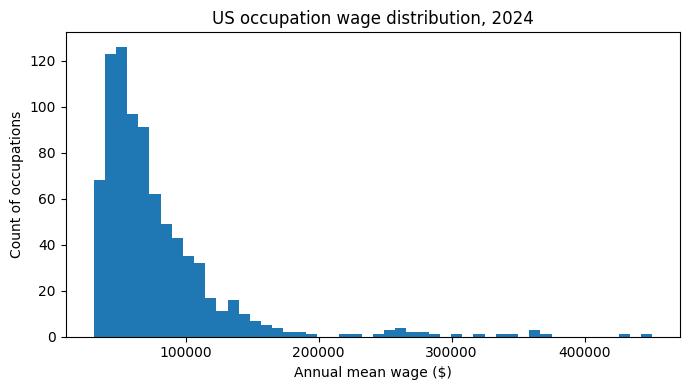

count       826.000000
mean      78130.205811
std       50647.186936
min       30830.000000
25%       48785.000000
50%       64315.000000
75%       90282.500000
max      450810.000000
Name: wage_annual_mean, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(latest["wage_annual_mean"].dropna(), bins=50)
ax.set_xlabel("Annual mean wage ($)")
ax.set_ylabel("Count of occupations")
ax.set_title(f"US occupation wage distribution, {int(latest['year'].iloc[0])}")
plt.tight_layout()
plt.show()

print(latest["wage_annual_mean"].describe())


## Regional comparison: US vs Florida

A real (unexpected) finding: Florida's median wage runs *below* the national median, not above it as the original project brief assumed (it expected a +3-8% cost-of-living premium).

In [4]:
latest_all = df[df["year"] == df["year"].max()]
common = set(latest_all[latest_all["region"]=="US"]["occ_code"]) & set(latest_all[latest_all["region"]=="FL"]["occ_code"])
latest_common = latest_all[latest_all["occ_code"].isin(common)]

summary = latest_common.groupby("region").agg(
    median_wage=("wage_annual_mean", "median"),
    median_emp_growth_pct=("employment_change_yoy_pct", "median"),
    pct_wage_decline=("wage_growth_yoy_pct", lambda s: (s < 0).mean() * 100),
    pct_contracting=("contraction_flag_12mo", lambda s: (s == 1).mean() * 100),
)
summary


,median_wage,median_emp_growth_pct,pct_wage_decline,pct_contracting
region,,,,
FL,57935.0,0.000000,21.112516,41.845765
US,63945.0,1.451722,10.113780,31.226296


## Top 10 contracting and top 10 growing US occupations (most recent year)

In [5]:
us_latest = latest_all[latest_all["region"] == "US"].dropna(subset=["employment_change_yoy_pct"])
cols = ["occ_title", "employment_level", "employment_change_yoy_pct", "wage_growth_yoy_pct"]
print("Top 10 contracting:")
display(us_latest.nsmallest(10, "employment_change_yoy_pct")[cols])
print("\nTop 10 growing:")
display(us_latest.nlargest(10, "employment_change_yoy_pct")[cols])


Top 10 contracting:


,occ_title,employment_level,employment_change_yoy_pct,wage_growth_yoy_pct
14482,Timing Device Assemblers and Adjusters,230.0,-42.500000,-19.738834
15040,"Model Makers, Wood",360.0,-38.983051,13.844982
15674,Subway and Streetcar Operators,9200.0,-38.088829,-2.261859
10508,Actors,38800.0,-37.979540,NaN
14920,"Sewers, Hand",2240.0,-33.923304,2.805670
14294,Watch and Clock Repairers,1300.0,-30.851064,11.239758
15050,"Patternmakers, Wood",180.0,-30.769231,10.682209
14910,Shoe Machine Operators and Tenders,3270.0,-29.373650,1.804758
10408,Special Effects Artists and Animators,21280.0,-28.924516,0.437836
14720,"Patternmakers, Metal and Plastic",1570.0,-26.976744,6.196150



Top 10 growing:


,occ_title,employment_level,employment_change_yoy_pct,wage_growth_yoy_pct
14234,"Refractory Materials Repairers, Except Brickma...",1100.0,103.703704,23.206413
12559,Models,5350.0,73.139159,18.689956
9990,"Law Teachers, Postsecondary",22800.0,56.485930,-1.748104
13848,"Underground Mining Machine Operators, All Other",3480.0,35.937500,3.890335
15644,"Rail Yard Engineers, Dinkey Operators, and Hos...",3300.0,35.802469,5.609587
12759,Correspondence Clerks,6260.0,34.623656,-0.703025
10823,Prosthodontists,760.0,33.333333,7.439252
10804,Oral and Maxillofacial Surgeons,5330.0,28.125000,7.756274
12549,Demonstrators and Product Promoters,64770.0,27.525103,6.424921
13197,Animal Breeders,1730.0,27.205882,4.914051


## Employment trend, selected occupations

A few of the largest occupations, national employment over time.

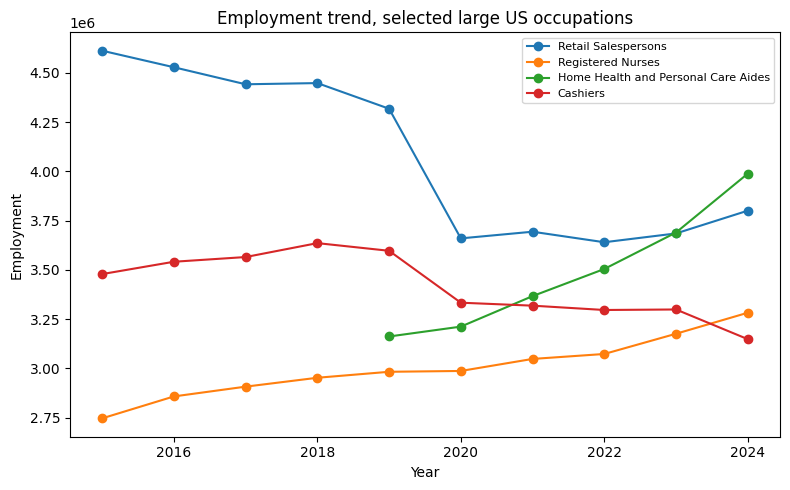

In [6]:
occupations_of_interest = ["Retail Salespersons", "Registered Nurses", "Home Health and Personal Care Aides", "Cashiers"]
fig, ax = plt.subplots(figsize=(8, 5))
for title in occupations_of_interest:
    sub = df[(df["occ_title"] == title) & (df["region"] == "US")].sort_values("year")
    if sub.empty:
        continue
    ax.plot(sub["year"], sub["employment_level"], marker="o", label=title)
ax.set_xlabel("Year")
ax.set_ylabel("Employment")
ax.set_title("Employment trend, selected large US occupations")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
